## 2R2C Thermal Building Model

To capture the thermal inertia of building envelopes more accurately than a simple **1R1C** model, a **2R2C network** can be introduced. The model separates the building into two thermal states:

- **Indoor air temperature** $T_i$
- **Wall (thermal mass) temperature** $T_w$

The system includes:

- Thermal capacitance of indoor air $k_a$.
- Thermal capacitance of the wall $k_w$.
- Thermal conductance between indoor air and wall $G_a$.
- Thermal conductance between wall and outdoor environment $G_w$.

External inputs to the system are:

- Outdoor temperature $T_o$.
- Heating power supplied to the building $\dot{Q}_h$.

---

## Energy Balance Equations:

Applying conservation of energy to each node gives the following differential equations.

### Indoor Air Node
$$
k_a \frac{dT_i}{dt}
=
G_a(T_w - T_i) + Q_h
$$

### Wall Node
$$
k_w \frac{dT_w}{dt}
=
G_w(T_o - T_w)
+
G_a (T_i - T_w)
$$

---

## State-Space Representation

Define the state vector $s = \begin{bmatrix} T_i \\ T_w \end{bmatrix}$ and the input vector $u = \begin{bmatrix} T_o \\ \dot{Q}_h \end{bmatrix}$. Then, the system can be written in the standard linear state-space form:
$$
\dot{s} = As + Bu
$$

## Stability Conclusion

One can show that the corresponding system matrix $A$ for this 2R2C system satisfies: $ \det(A) > 0 $ and $ \text{tr}(A) < 0$. Thus, the eigenvalues of the system matrix $A$ lie in the **left half of the complex plane**, and the 2R2C thermal model is therefore **asymptotically stable**. Physically, this reflects that a passive thermal system with positive resistances and capacitances cannot generate energy and will always relax toward equilibrium.

## Demonstration

We consider a single building envelope under the 2R2C model and further assume we have a controller that can instantaneously supply heating power $\dot{Q}_h$ to the building envelope. We further assume a simple thermostat setpoint schedule:

$$
T_\text{set} = 21^\circ \text{if daytime, else} \ 18^\circ
$$

where daytime occurs between $08.00$ AM and $21.00$ PM. 

The controller supplies heating power to the building whenever $T_i < T_\text{set}$ and starts to apply the maximum heating power $\dot{Q}_h = \dot{Q}_\text{max}$ else, the controller does nothing $\dot{Q}_h = 0$.

In [1]:
import matplotlib.pyplot as plt
from pydas.simulation_manager import RCBuilding2R2C, SupplyController # Importing necessary simulator tools.
from pydas.utilities import ClimateData

parameters_2R2C = { # There are four parameters (two resistances and two capacitances).
    "thermal_capacitance_air": 5.0, # In units of kWh / K.,
    "thermal_conductance_air": 0.5, # In units of Kw / K.
    "thermal_capacitance_wall": 50.0, # In units of kWh / K.,
    "thermal_conductance_wall": 0.3, # In units of Kw / K. 
}

In [3]:
timestep = 1.0 # Amounts to one hour resolution.
temperature_data = ClimateData.load_csv_from_smhi(path_to_file = "../data/smhi_gotenburg.csv", type = "Lufttemperatur") # For now, loading a weather file that has at least hourly resolution which is a station in Gothenburg.
controller = SupplyController(maximum_heating_power = 10.0) # An external "controller" that supplies heating power instantaneously.
rcbuilding = RCBuilding2R2C(parameters = parameters_2R2C) # A RC model instance for the considered building.

In [4]:
## Allocate some lists for storing temperature states.
recorded_indoor_temperatures = []
recorded_wall_temperatures = []
recorded_setpoints = []
number_of_iterations = len(bes.outdoor_temperature_data.index)
print(f"Simulation will contain {number_of_iterations} one-hour timesteps.")

Simulation will contain 3139 one-hour timesteps.


In [5]:
%%time
for it in range(number_of_iterations):
    recorded_setpoints.append(rcbuilding.setpoint_temperature_callback(bes.outdoor_temperature_data["timestamp"].dt.hour[it])) # Get the current setpoint temperature, based on a very simple rule.
    recorded_indoor_temperatures.append(rcbuilding.state["indoor_temperature"]) # Get the corresponding instantaneous indoor temperature.
    recorded_wall_temperatures.append(rcbuilding.state["wall_temperature"]) # Get the corresponding instantaneous wall temperature.
    bes.step() # Update the simulation one hour forward (one timestep).

CPU times: total: 1.42 s
Wall time: 1.46 s


(1000.0, 1500.0)

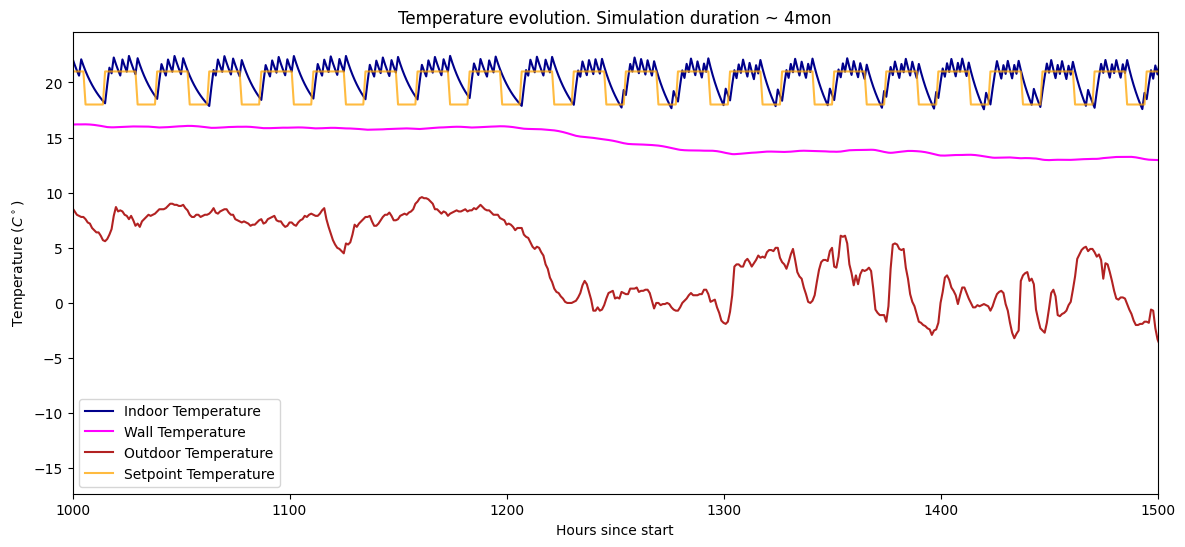

In [6]:
plt.figure(figsize = (14, 6))
plt.plot(recorded_indoor_temperatures, label = "Indoor Temperature", color = "darkblue")
plt.plot(recorded_wall_temperatures, label = "Wall Temperature", color = "magenta")
plt.plot(bes.outdoor_temperature_data["Lufttemperatur"], label = "Outdoor Temperature", color = "firebrick")
plt.plot(recorded_setpoints, color = "orange", label = "Setpoint Temperature", alpha = 0.75)
plt.title("Temperature evolution. Simulation duration ~ 4mon")
plt.xlabel("Hours since start")
plt.ylabel("Temperature $(C^\\circ)$")
plt.legend()

plt.xlim(1000, 1500)